# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Ghiyyas Abiyasha Winardi
- **Email:** yashnime29@gmail.com
- **ID Dicoding:** CDCC009D6Y2471

## Menentukan Pertanyaan Bisnis

- ***Pertanyaan 1:***

    Bagaimana variasi rata-rata jumlah penyewaan sepeda jika dibandingkan antar kondisi cuaca selama periode 2011–2012?

- ***Pertanyaan 2:***

    Pada pukul berapa dalam sehari jumlah rata-rata penyewaan sepeda berada pada titik tertinggi selama tahun 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Mengimpor semua library yang dibutuhkan 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
data_dir = "data/"

## Data Wrangling

### Gathering Data

In [2]:
# Mengimpor data dari file eksternal (csv) ke dalam program python
day_df = pd.read_csv(os.path.join(data_dir, "day.csv"))

# Menampilkan 5 baris pertama dari Dataframe tersebut
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
# Mengimpor data dari file eksternal (csv) ke dalam program python
hour_df = pd.read_csv(os.path.join(data_dir, "hour.csv"))

# Menampilkan 5 baris pertama dari Dataframe tersebut
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Dataset day.csv dan hour.csv telah berhasil dibaca dan berisi data penyewaan sepeda dalam dua skala waktu, yaitu harian dan per jam. Dengan adanya dua level ini, analisis bisa dilakukan secara menyeluruh, baik untuk mengamati tren jangka panjang maupun pola penggunaan dalam satu hari. Data yang tersedia tidak hanya mencakup total penyewaan sepeda (cnt), tetapi juga dilengkapi dengan variabel lingkungan seperti suhu (temp), kelembaban (hum), kecepatan angin (windspeed), serta kondisi cuaca (weathersit). Hal ini membuka peluang untuk mengkaji hubungan antara faktor lingkungan dengan tingkat penyewaan sepeda. Selain itu, dataset memuat atribut waktu dan tipe pengguna, seperti musim (season), bulan (mnth), hari (weekday), status hari kerja (workingday), serta jumlah pengguna casual dan registered. Informasi ini dapat dimanfaatkan untuk mengeksplorasi pola penggunaan sepeda berdasarkan waktu sekaligus membandingkan perilaku antara kedua jenis pengguna tersebut.


### Assessing Data

In [4]:
# Memeriksa tipe data dari setiap kolom
day_df.info()
print("========================================")
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [5]:
# Cek Missing Value dari dataset
print("Missing Value dataset day.csv:\n", day_df.isnull().sum())
print("\nMissing Value dataset hour.csv:\n", hour_df.isnull().sum())

Missing Value dataset day.csv:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Missing Value dataset hour.csv:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [6]:
# Cek duplikasi data menggunakan 'duplicated()'
day_df.duplicated().sum()
hour_df.duplicated().sum()

0

In [7]:
# Cek statistik deskriptif data
day_df.describe()
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**

Dari hasil pengecekan struktur data menggunakan .info(), terlihat bahwa kolom dteday masih bertipe object. Tipe ini kurang sesuai karena merepresentasikan data waktu, sehingga pada tahap data cleaning perlu dikonversi menjadi tipe datetime agar lebih tepat untuk analisis berbasis waktu. Hasil identifikasi missing values pada dataset day.csv dan hour.csv menunjukkan bahwa tidak terdapat nilai yang hilang di seluruh kolom. Kondisi ini menandakan data sudah lengkap, sehingga tidak diperlukan penanganan khusus terkait data kosong sebelum proses analisis dilakukan. Berdasarkan pengecekan data duplikat serta tinjauan statistik deskriptif, tidak ditemukan adanya duplikasi data maupun anomali seperti nilai negatif pada variabel numerik. Hal ini mengindikasikan bahwa kualitas data cukup baik dan layak untuk langsung digunakan pada tahap analisis selanjutnya.

### Cleaning Data

In [8]:
# Mengubah tipe data 'dteday' menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Cek perubahan
day_df.info()
print("========================================")
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [9]:
# Mapping musim (season)
season_labels = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

# Mapping cuaca (weathersit)
weather_labels = {
    1: 'Clear',
    2: 'Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain'
}

# Menerapkan mapping pada day_df
day_df['season'] = day_df['season'].map(season_labels)
day_df['weathersit'] = day_df['weathersit'].map(weather_labels)

# Menerapkan mapping pada hour_df
hour_df['season'] = hour_df['season'].map(season_labels)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_labels)

# Cek perubahan
print("Musim :", day_df['season'].unique())
print("Cuaca :", day_df['weathersit'].unique())

Musim : ['Spring' 'Summer' 'Fall' 'Winter']
Cuaca : ['Cloudy' 'Clear' 'Light Snow/Rain']


**Insight:**

Kolom dteday sudah diubah ke tipe data datetime, sehingga urutan waktu seperti tahun, bulan, dan hari dapat dikenali secara sistematis oleh sistem. Perubahan ini membuat analisis berbasis waktu, termasuk identifikasi tren penyewaan sepeda dari tahun ke tahun, dapat dilakukan dengan lebih akurat dibandingkan saat masih menggunakan tipe object. Transformasi pada kolom season dan weathersit dilakukan melalui proses mapping untuk meningkatkan keterbacaan data. Nilai numerik diubah menjadi label yang lebih deskriptif (misalnya “Spring” atau “Clear”), sehingga interpretasi data menjadi lebih mudah. Dari hasil ini juga terlihat bahwa kondisi cuaca yang ekstrem muncul dengan frekuensi yang relatif sedikit dalam dataset.

## Exploratory Data Analysis (EDA)

### Explore ...

In [10]:
# Melihat rangkuman parameter statistik dari kedua dataset
day_df.describe(include="all")
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,NaN,NaN,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [11]:
# Mengelompokkan berdasarkan cuaca dan menghitung rata-rata penyewaan
weather_rentals = day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False).reset_index()

# Menampilkan rata-rata penyewaan di setiap cuaca
print(weather_rentals)

        weathersit          cnt
0            Clear  4876.786177
1           Cloudy  4035.862348
2  Light Snow/Rain  1803.285714


In [12]:
# Mengelompokkan berdasarkan jam (hr) dan menghitung rata-rata penyewaan
hourly_rentals = hour_df.groupby('hr')['cnt'].mean().sort_values(ascending=False).reset_index()

# Menampilkan 5 besar jam tersibuk
print(hourly_rentals.head(5))

   hr         cnt
0  17  461.452055
1  18  425.510989
2   8  359.011004
3  16  311.983562
4  19  311.523352


In [13]:
# Melakukan seleksi kolom yang relevan dengan pertanyaan bisnis untuk melihat korelasi
relevant_day_cols = ['cnt', 'temp', 'atemp', 'hum', 'windspeed', 'yr']
relevant_hour_cols = ['cnt', 'hr', 'temp', 'atemp', 'hum', 'windspeed', 'registered', 'casual']

# Korelasi variabel numerik pada dataset harian (day_df) terhadap jumlah total penyewaan (cnt)
correlation_day = day_df[relevant_day_cols].corr()['cnt'].sort_values(ascending=False)

# Korelasi variabel numerik pada dataset per-jam (hour_df) terhadap jumlah total penyewaan (cnt)
correlation_hour = hour_df[relevant_hour_cols].corr()['cnt'].sort_values(ascending=False)

# Menampilkan hasil korelasi
print(correlation_day)
print("=========================================")
print(correlation_hour)

cnt          1.000000
atemp        0.631066
temp         0.627494
yr           0.566710
hum         -0.100659
windspeed   -0.234545
Name: cnt, dtype: float64
cnt           1.000000
registered    0.972151
casual        0.694564
temp          0.404772
atemp         0.400929
hr            0.394071
windspeed     0.093234
hum          -0.322911
Name: cnt, dtype: float64


**Insight:**

Hasil analisis mengindikasikan bahwa tingkat penyewaan sepeda dipengaruhi oleh perpaduan antara kondisi cuaca dan pola aktivitas harian. Cuaca cerah (Clear) berkaitan dengan rata-rata penggunaan tertinggi, mencapai sekitar 4.876 penyewaan. Sementara itu, lonjakan permintaan paling signifikan terjadi pada jam-jam sibuk, khususnya pukul 08.00, 17.00, dan 18.00. Temuan ini menunjukkan bahwa layanan bike sharing berperan penting dalam mobilitas sehari-hari. Namun, operasionalnya cukup sensitif terhadap kondisi lingkungan, sehingga optimalisasi layanan sebaiknya difokuskan pada periode puncak, terutama saat cuaca mendukung. Analisis lebih lanjut menunjukkan bahwa faktor suhu, baik suhu aktual (temp) maupun suhu yang dirasakan (atemp), memiliki pengaruh paling kuat terhadap jumlah penyewaan harian dengan korelasi yang cukup tinggi (0,63). Sebaliknya, kelembapan dan kecepatan angin cenderung memberikan dampak negatif terhadap tingkat penggunaan. Pada tingkat per jam, peran pengguna terdaftar (registered) sangat dominan dengan korelasi yang hampir sempurna (0,97), menandakan bahwa pola komuter rutin menjadi faktor utama dalam lonjakan penyewaan pada waktu tertentu, dibandingkan pengguna kasual. Selain itu, pengaruh negatif kelembapan yang lebih besar pada data per jam (-0,32) menunjukkan bahwa kenyamanan udara secara langsung memengaruhi keputusan pengguna dalam jangka waktu yang lebih spesifik. Temuan ini juga sejalan dengan adanya tren pertumbuhan bisnis yang positif selama periode analisis, dengan korelasi tahunan sebesar 0,56.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

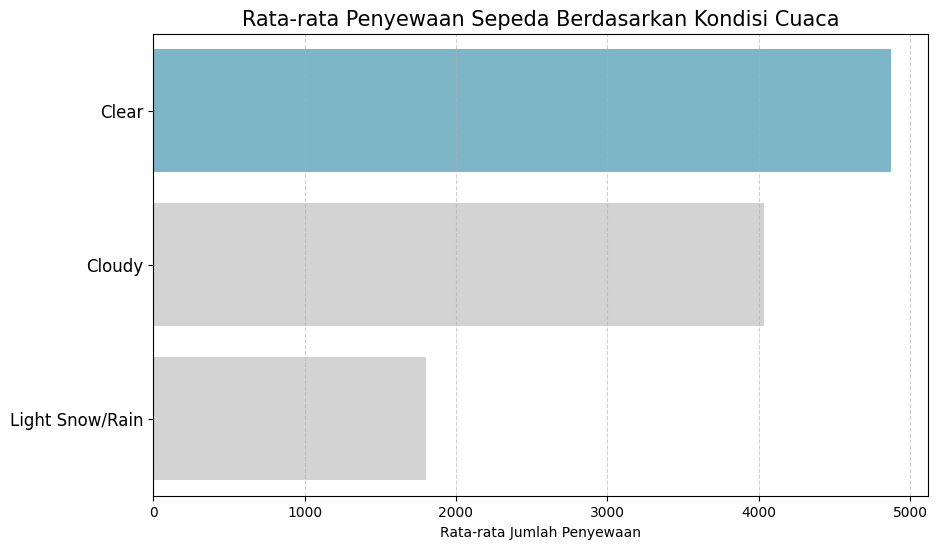

In [14]:
# Membuat visualisasi Bar Chart untuk pertanyaan bisnis 1
plt.figure(figsize=(10, 6))

# Menentukan warna: Biru cerah untuk yang tertinggi, abu-abu untuk lainnya
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x='cnt',
    y='weathersit',
    data=weather_rentals.sort_values(by='cnt', ascending=False),
    palette=colors
)

# Menambahkan Judul dan Label
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca', loc='center', fontsize=15)
plt.ylabel(None)
plt.xlabel('Rata-rata Jumlah Penyewaan')
plt.tick_params(axis='y', labelsize=12)

# Menambahkan garis bantu (grid) pada sumbu x
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

**Insight:**   

Dari hasil analisis terlihat bahwa kondisi cuaca memiliki pengaruh yang sangat kuat terhadap perilaku pengguna dalam menyewa sepeda. Ketika cuaca berada dalam kondisi cerah (Clear), tingkat penyewaan mencapai angka tertinggi karena pengguna merasa lebih nyaman dan aman untuk beraktivitas di luar ruangan. Sebaliknya, saat cuaca berubah menjadi kurang mendukung seperti hujan ringan atau salju (Light Snow/Rain), jumlah penyewaan mengalami penurunan yang signifikan. Penurunan ini menunjukkan bahwa keputusan pengguna sangat dipengaruhi oleh faktor kenyamanan dan risiko saat berkendara. Artinya, meskipun layanan bike sharing cukup diminati, tingkat penggunaannya tidak sepenuhnya stabil dan sangat bergantung pada kondisi lingkungan. Dengan demikian, dapat dipahami bahwa fluktuasi permintaan harian bukan hanya disebabkan oleh pola aktivitas manusia, tetapi juga oleh perubahan cuaca. Hal ini menjadi indikasi penting bahwa dalam operasional bisnis, faktor cuaca perlu dipertimbangkan sebagai salah satu variabel utama dalam memprediksi jumlah penyewaan dan mengatur strategi layanan.

### Pertanyaan 2:

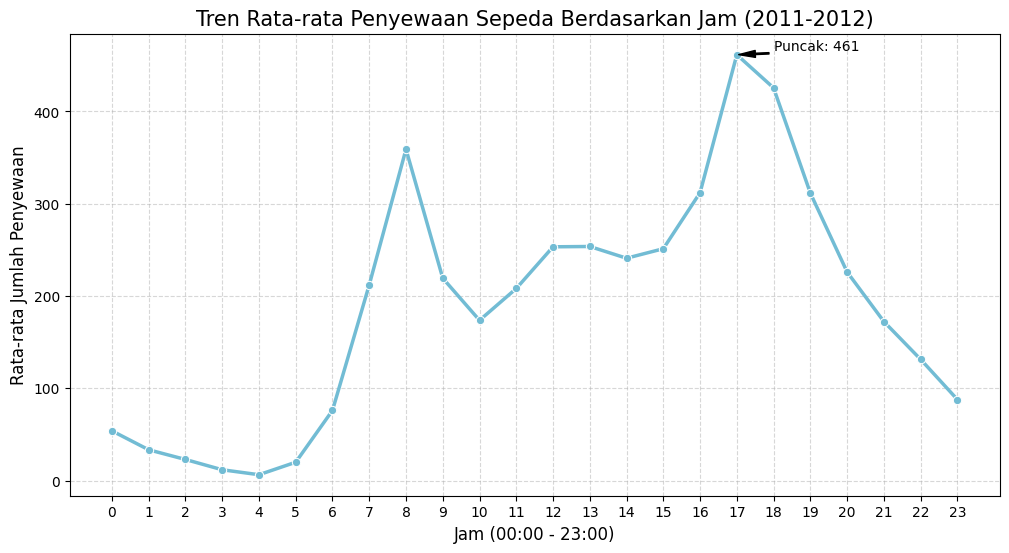

In [15]:
# Membuat visualisasi Line Chart
plt.figure(figsize=(12, 6))

sns.lineplot(
    x='hr',
    y='cnt',
    data=hourly_rentals,
    marker='o',
    linewidth=2.5,
    color='#72BCD4'
)

# Menambahkan judul dan label
plt.title('Tren Rata-rata Penyewaan Sepeda Berdasarkan Jam (2011-2012)', fontsize=15)
plt.xlabel('Jam (00:00 - 23:00)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)

# Mengatur agar semua angka jam (0-23) muncul di sumbu X
plt.xticks(range(0, 24))

# Menambahkan garis bantu (grid) agar lebih mudah membaca nilai
plt.grid(True, linestyle='--', alpha=0.5)

# Menambahkan anotasi pada titik tertinggi (pukul 17:00)
peak_hour = 17
peak_value = hourly_rentals.loc[hourly_rentals['hr'] == peak_hour, 'cnt'].values[0]
plt.annotate(f'Puncak: {peak_value:.0f}',
             xy=(peak_hour, peak_value),
             xytext=(peak_hour+1, peak_value+5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.show()

**Insight:**   

Hasil visualisasi per jam menunjukkan adanya pola penggunaan sepeda yang sangat selaras dengan rutinitas komuter. Permintaan tidak tersebar secara merata sepanjang hari, melainkan terkonsentrasi pada jam-jam tertentu yang berkaitan dengan aktivitas kerja. Terlihat dua lonjakan utama, yaitu sekitar pukul 08.00 saat orang memulai aktivitas, dan pukul 17.00 ketika aktivitas berakhir. Puncak tertinggi terjadi pada sore hari dengan rata-rata sekitar 461 penyewaan. Pola dua lonjakan ini mengindikasikan bahwa sepeda berperan sebagai moda transportasi rutin harian. Di sisi lain, periode dini hari, khususnya antara pukul 00.00 hingga 05.00, menunjukkan tingkat penggunaan paling rendah, sehingga menjadi waktu yang paling memungkinkan untuk kegiatan operasional seperti perawatan. Pola penyewaan sepeda mengikuti kebiasaan aktivitas harian manusia, khususnya pekerja atau komuter. Lonjakan penggunaan di pagi dan sore hari mencerminkan kebutuhan transportasi untuk berangkat dan pulang kerja. Tingginya penyewaan di sore hari dibanding pagi hari bisa menunjukkan bahwa lebih banyak orang memilih menggunakan sepeda saat pulang, atau aktivitas mereka lebih fleksibel di waktu tersebut. Rendahnya penggunaan pada dini hari menandakan minimnya kebutuhan transportasi di jam tersebut, sehingga waktu ini bisa dimanfaatkan untuk kegiatan internal seperti maintenance tanpa mengganggu pengguna. Secara keseluruhan, pola ini menegaskan bahwa layanan bike sharing sangat terintegrasi dengan ritme kehidupan sehari-hari, bukan sekadar digunakan untuk rekreasi.

## Analisis Lanjutan (Opsional)

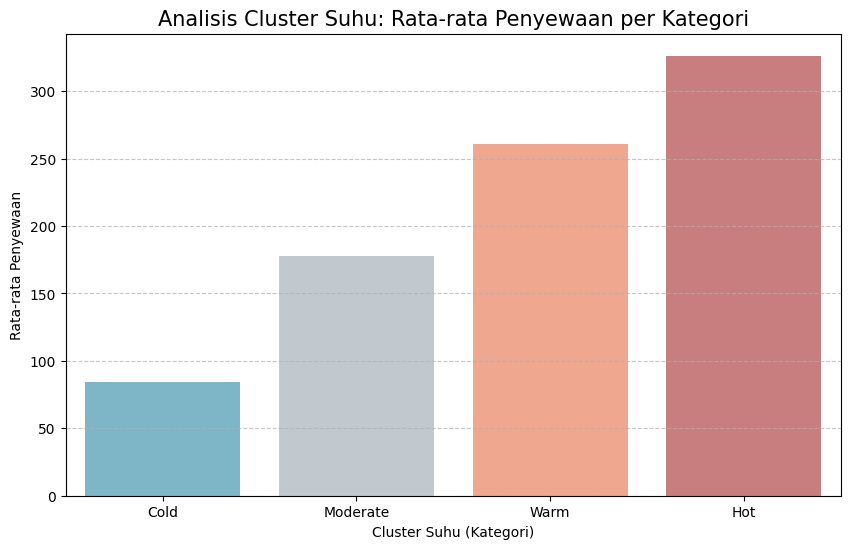

In [16]:
# Melakukan analisis lanjutan Clustering dengan menggunakan metode Binning
# Menentukan Range (Bin) dan Label
# Membagi suhu (temp) menjadi 4 kategori: Cold, Moderate, Warm, Hot
bins = [0, 0.3, 0.6, 0.8, 1.0]
labels = ['Cold', 'Moderate', 'Warm', 'Hot']

# Menerapkan Binning (Clustering Manual) dengan membuat kolom baru bernama 'temp_cluster'
hour_df['temp_cluster'] = pd.cut(hour_df['temp'], bins=bins, labels=labels, include_lowest=True)

# Agregasi Data berdasarkan Cluster
temp_cluster_analysis = hour_df.groupby('temp_cluster', observed=True).agg({
    'cnt': 'mean'
}).reset_index()

# Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))
colors = ["#72BCD4", "#BFCAD0", "#FF9F80", "#D47272"]

sns.barplot(
    x='temp_cluster',
    y='cnt',
    data=temp_cluster_analysis,
    palette=colors
)

# Menambahkan judul dan label
plt.title('Analisis Cluster Suhu: Rata-rata Penyewaan per Kategori', fontsize=15)
plt.xlabel('Cluster Suhu (Kategori)')
plt.ylabel('Rata-rata Penyewaan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Conclusion

### **Conclution pertanyaan 1:**

Kondisi cuaca memiliki peran yang sangat besar dalam menentukan minat masyarakat untuk menyewa sepeda.

- **Penggunaan Tertinggi:** Pada saat cuaca cerah, tingkat penyewaan mencapai angka tertinggi dengan rata-rata sekitar 4.877 sepeda per hari.

- **Penggunaan Terendah:** Ketika cuaca memburuk, seperti hujan ringan atau salju, jumlah penyewaan turun drastis menjadi sekitar 1.803 sepeda, atau berkurang lebih dari setengah dibanding kondisi cerah.

- **Alasannya:** Hal ini terjadi karena pengguna cenderung mencari kenyamanan dan keamanan saat bersepeda, sehingga kondisi cuaca yang kurang mendukung membuat mereka enggan menggunakan layanan ini.

### **Saran / Rekomendasi**   
- **Strategi Promosi Berbasis Cuaca:** Tawarkan insentif seperti diskon atau reward tambahan saat cuaca kurang ideal untuk menjaga minat pengguna tetap stabil.

- **Optimasi Waktu Promosi:** Arahkan kampanye pemasaran pada hari-hari dengan prakiraan cuaca baik agar potensi penyewaan bisa dimaksimalkan.

- **Peningkatan Layanan:** Menyediakan perlengkapan tambahan seperti jas hujan dapat membantu pengguna tetap merasa nyaman saat terjadi perubahan cuaca mendadak.

---
### **Conclution pertanyaan 2:**

Pola penggunaan sepeda menunjukkan bahwa layanan ini banyak dimanfaatkan sebagai sarana transportasi rutin, khususnya untuk aktivitas harian seperti bekerja atau sekolah.

- **Waktu Puncak:** Lonjakan penyewaan terjadi pada jam sibuk, yaitu sekitar pukul 08.00 pagi dan mencapai puncaknya pada pukul 17.00 sore dengan rata-rata sekitar 461 penyewaan.

- **Waktu Sepi:** Aktivitas terendah terjadi pada rentang tengah malam hingga dini hari (00.00–05.00).

- **Alasannya:** Pengguna memanfaatkan sepeda sebagai alternatif transportasi yang lebih efisien untuk menghindari kemacetan, terutama pada jam berangkat dan pulang kerja.

### **Saran / Rekomendasi**   
- **Manajemen Distribusi Sepeda:** Pastikan ketersediaan sepeda mencukupi di area strategis seperti perumahan pada pagi hari dan area perkantoran pada sore hari.

- **Penjadwalan Perawatan:** Lakukan aktivitas perbaikan dan pengecekan sepeda pada jam-jam sepi agar tidak mengganggu operasional saat permintaan tinggi.

- **Program Langganan:** Kembangkan paket berlangganan khusus bagi pengguna rutin di jam sibuk untuk meningkatkan retensi pelanggan.

In [17]:
# Mengekspor hour_df.csv ke file utama main_data.csv
# File utama akan digunakan dalam pembuatan dashboard menggunakan streamlit
hour_df.to_csv("main_data.csv", index=False)